In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

# JOB Main Figure (Figure 17)

In [60]:
early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
files = glob.glob('origin_data/job_result/*.txt')
data_frames = []
for query_name in queries:
    result = pd.read_csv(f'origin_data/job_result/{query_name}.txt')
    result['query'] = query_name 
    data_frames.append(result)
    
combined_df = pd.concat(data_frames, ignore_index=True)   

combined_df
    

,key,latency,result_size,thread_num,mat_strat,queue_thr,map_building_time,materialize_time,sink_hash_join_time,others,io_time,total_latency_2,query
0,EM,109.6680,1.0,1.0,0.0,0.0,0.00,0.00,0.49,18.46,90.72,109.67,1d
1,Best,68.4778,1.0,1.0,1.0,10.0,0.01,3.81,0.45,16.64,47.57,68.48,1d
2,select,68.4778,1.0,1.0,1.0,10.0,0.01,3.81,0.45,16.64,47.57,68.48,1d
3,LM,72.2900,1.0,1.0,1.0,10.0,0.01,7.08,0.15,17.47,47.57,72.29,1d
4,EM,369.8970,1.0,1.0,0.0,0.0,0.00,0.00,7.53,66.22,296.14,369.90,2a
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,LM,24.8440,0.0,1.0,1.0,10.0,0.00,0.00,0.00,20.79,4.06,24.84,32a
128,EM,388.2950,1.0,1.0,0.0,0.0,0.00,0.00,2.51,79.40,306.38,388.30,33a
129,select,308.8130,0.0,1.0,1.0,1000.0,0.00,0.00,1.99,75.15,231.67,308.81,33a
130,Best,307.1550,0.0,1.0,1.0,1000.0,0.00,0.00,2.00,78.03,227.12,307.15,33a


In [61]:
query1 = combined_df[(combined_df['key'] == 'EM')&(combined_df['latency']<1500)]['query']

In [62]:
def plot_data(df, queries):
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    color_map=['#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']

    strategies = ['EM', 'LM','Best','select']
    bar_width = 0.21
    index = range(len(queries))
    
    fig, ax = plt.subplots(figsize=(50, 10))

    label_name = ['Pure EM', 'Pure LM','Optimal','SLM']
    for i, strategy in enumerate(strategies):
        strategy_data = df[df['key'] == strategy]
        latencies = strategy_data['latency']
        # print((latencies))
        io_time = strategy_data['io_time']
        others = strategy_data['others']
        sink_hash_join_time = strategy_data['sink_hash_join_time']
        materialize_time = strategy_data['materialize_time']
        map_building_time = strategy_data['map_building_time']
        ax.bar([x + i * bar_width for x in index], latencies, bar_width, color=color_map[i],edgecolor='grey', label = label_name[i])
        bottom = 0
        ax.bar([x + i * bar_width for x in index], io_time, bar_width,bottom = bottom, color='none',edgecolor='black',hatch='/', label = 'I/O Time'if i == 3 else "")
        bottom += io_time
        ax.bar([x + i * bar_width for x in index], others, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='.', label='Others'if i == 3 else "")
        bottom += others
        ax.bar([x + i * bar_width for x in index], sink_hash_join_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='x', label = 'Hash Build'if i == 3 else "")
        bottom += sink_hash_join_time
        ax.bar([x + i * bar_width for x in index], materialize_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='+', label = 'Materialize'if i == 3 else "")
        bottom += materialize_time
        ax.bar([x + i * bar_width for x in index], map_building_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='', label = 'Map Building'if i == 3 else "")
    
    late = np.array(df[df['key'] == 'Best']['latency'])
    early = np.array(df[df['key'] == 'EM']['latency'])
    slm = np.array(df[df['key'] == 'select']['latency'])
    enhance = (early - slm)*100/early
    for i in range(len(index)):
        plt.text(index[i] + bar_width*1.5 , late[i]*1.05+130, '%.1f'%enhance[i]+'%', fontsize = 38)
    print(sum(enhance)/len(enhance))

    slm_best = (slm-late)*100/slm
    print(slm_best)
    for i in range(len(index)):
        plt.text(index[i] + bar_width*1.5 , late[i]*1.05+10, '-%.1f'%slm_best[i]+'%', fontsize = 39,color='blue')
            
    
    # ax.set_xlabel('JOB Query', fontsize = 45)
    ax.set_ylabel('Latency (ms)', fontsize = 45)
    # ax.set_title('Latency Comparison for Different Queries', fontsize = 45)
    ax.set_xticks([i + bar_width * 2 for i in index])
    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize = 35)
    ax.set_xlim(-2*bar_width, len(queries) - 0.5 + 2.5*bar_width)
    ax.set_ylim(0,2000)
    ax.legend(fontsize=41,ncol=2, loc='upper left')
    
    fig_name = 'job_total1'
    plt.tight_layout()
    plt.savefig(f"paper_figure/job/{fig_name}.pdf",bbox_inches='tight')
    plt.show()
    return slm_best


In [63]:
query1 = combined_df[(combined_df['key'] == 'LM')&(combined_df['latency']<1300)]['query']
combined_df1 = combined_df[combined_df['query'].isin( query1)]

16.34568545654582
[0.         1.11316106 7.98421848 0.         0.         0.
 0.         2.39377899 0.         0.         0.         0.
 0.         4.2368877  0.         0.77641047 0.5368945 ]


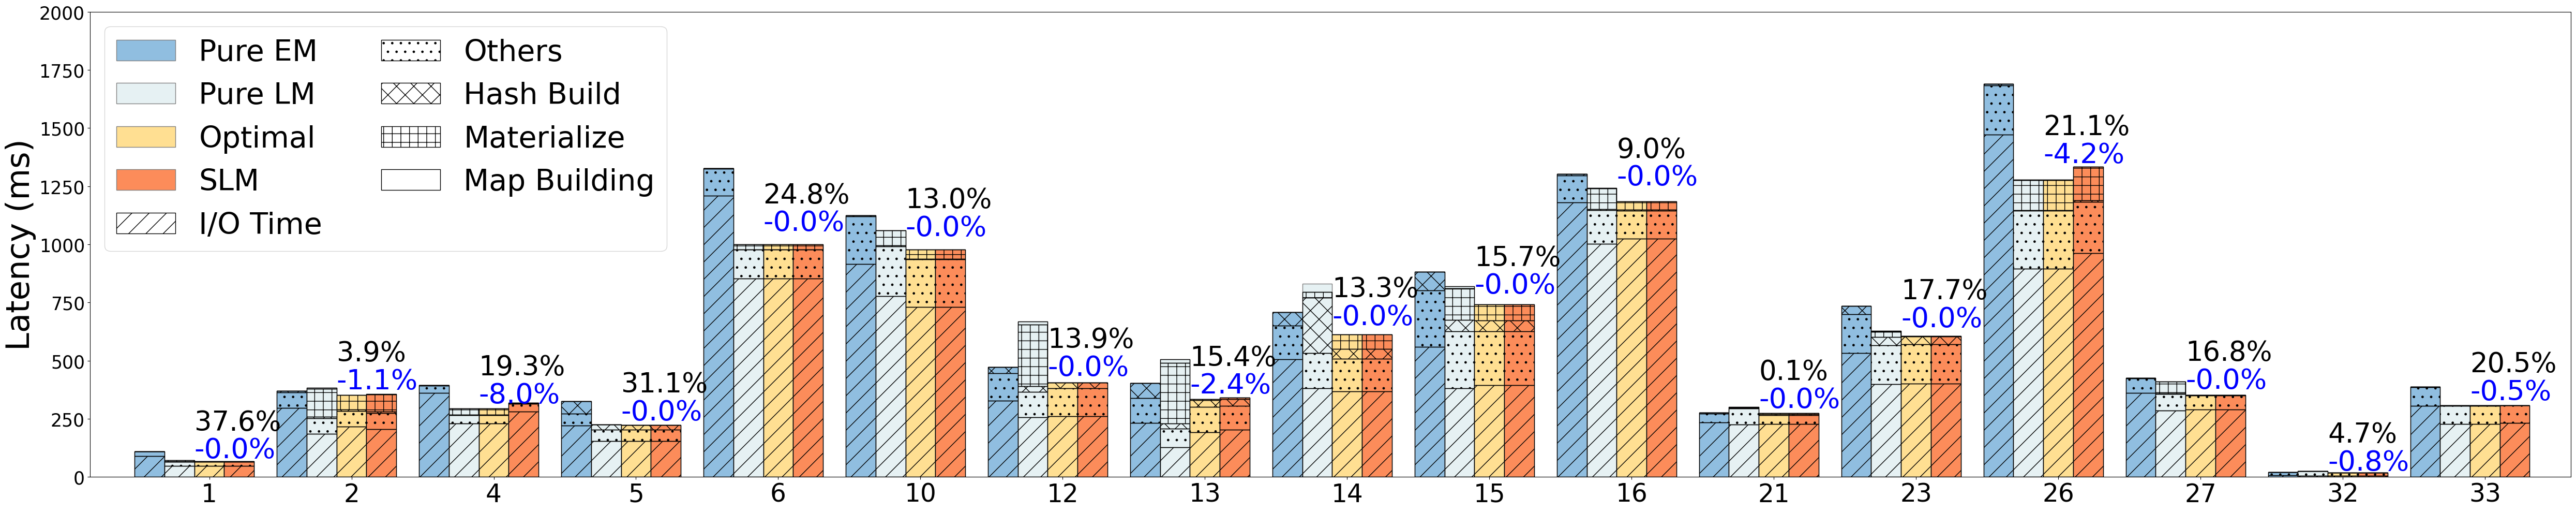

In [64]:
slm_best1 = plot_data(combined_df1,query1)

In [65]:
def plot_data(df, queries):
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    color_map=['#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']

    strategies = ['EM', 'LM','Best','select']
    bar_width = 0.21
    index = range(len(queries))
    
    fig, ax = plt.subplots(figsize=(50, 10))

    label_name = ['Pure EM', 'Pure LM','Best','Selective LM']
    for i, strategy in enumerate(strategies):
        strategy_data = df[df['key'] == strategy]
        latencies = strategy_data['latency']
        # print((latencies))
        io_time = strategy_data['io_time']
        others = strategy_data['others']
        sink_hash_join_time = strategy_data['sink_hash_join_time']
        materialize_time = strategy_data['materialize_time']
        map_building_time = strategy_data['map_building_time']
        ax.bar([x + i * bar_width for x in index], latencies, bar_width, color=color_map[i],edgecolor='grey', label = strategy)
        bottom = 0
        ax.bar([x + i * bar_width for x in index], io_time, bar_width,bottom = bottom, color='none',edgecolor='black',hatch='/', label = 'IO Time'if i == 3 else "")
        bottom += io_time
        ax.bar([x + i * bar_width for x in index], others, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='.', label='Others'if i == 3 else "")
        bottom += others
        ax.bar([x + i * bar_width for x in index], sink_hash_join_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='x', label = 'Hash Build Time'if i == 3 else "")
        bottom += sink_hash_join_time
        ax.bar([x + i * bar_width for x in index], materialize_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='+', label = 'Materialize Time'if i == 3 else "")
        bottom += materialize_time
        ax.bar([x + i * bar_width for x in index], map_building_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='', label = 'Map Building Time'if i == 3 else "")
    
    late = np.array(df[df['key'] == 'Best']['latency'])
    early = np.array(df[df['key'] == 'EM']['latency'])
    slm = np.array(df[df['key'] == 'select']['latency'])
    enhance = (early - slm)*100/early
    for i in range(len(index)):
        if index[i] in [3,4,7,8,9]:
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05+250, '%.1f'%enhance[i]+'%', fontsize = 38)
        # elif index[i] in [9,10]:
        #     plt.text(index[i] + bar_width*0.6 , late[i]*1.25, '%.1f'%enhance[i]+'%', fontsize = 38)
        else:
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05+250, '%.1f'%enhance[i]+'%', fontsize = 38)
    print(sum(enhance)/len(enhance))

    slm_best = (slm-late)*100/slm
    print(slm_best)
    for i in range(len(index)):
        if index[i] in [3,4,7,8,9]:
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05+20, '-%.1f'%slm_best[i]+'%', fontsize = 38,color='blue')
        else:
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05+20, '-%.1f'%slm_best[i]+'%', fontsize = 38,color='blue')

            
    # ax.set_xlabel('JOB Query', fontsize = 45)
    ax.set_ylabel('Latency (ms)', fontsize = 45)
    # ax.set_title('Latency Comparison for Different Queries', fontsize = 45)
    ax.set_xticks([i + bar_width * 2 for i in index])
    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize = 35)
    ax.set_xlim(-2*bar_width, len(queries) - 0.5 + 2.5*bar_width)
    ax.set_ylim(0,4450)
    # ax.legend(fontsize=35,ncol=2)
    
    fig_name = 'job_total2'
    plt.tight_layout()
    plt.savefig(f"paper_figure/job/{fig_name}.pdf",bbox_inches='tight')
    plt.show()
    return slm_best

In [66]:
query2 = combined_df[(combined_df['key'] == 'LM')&(combined_df['latency']>=1300)]['query']
combined_df2 = combined_df[combined_df['query'].isin( query2)]

12.87192846012779
[0.         0.         1.4252839  1.99859921 0.27225517 0.
 0.46880173 0.         0.         0.         1.28554172 2.116568
 0.         3.80205514 0.         2.84463197]


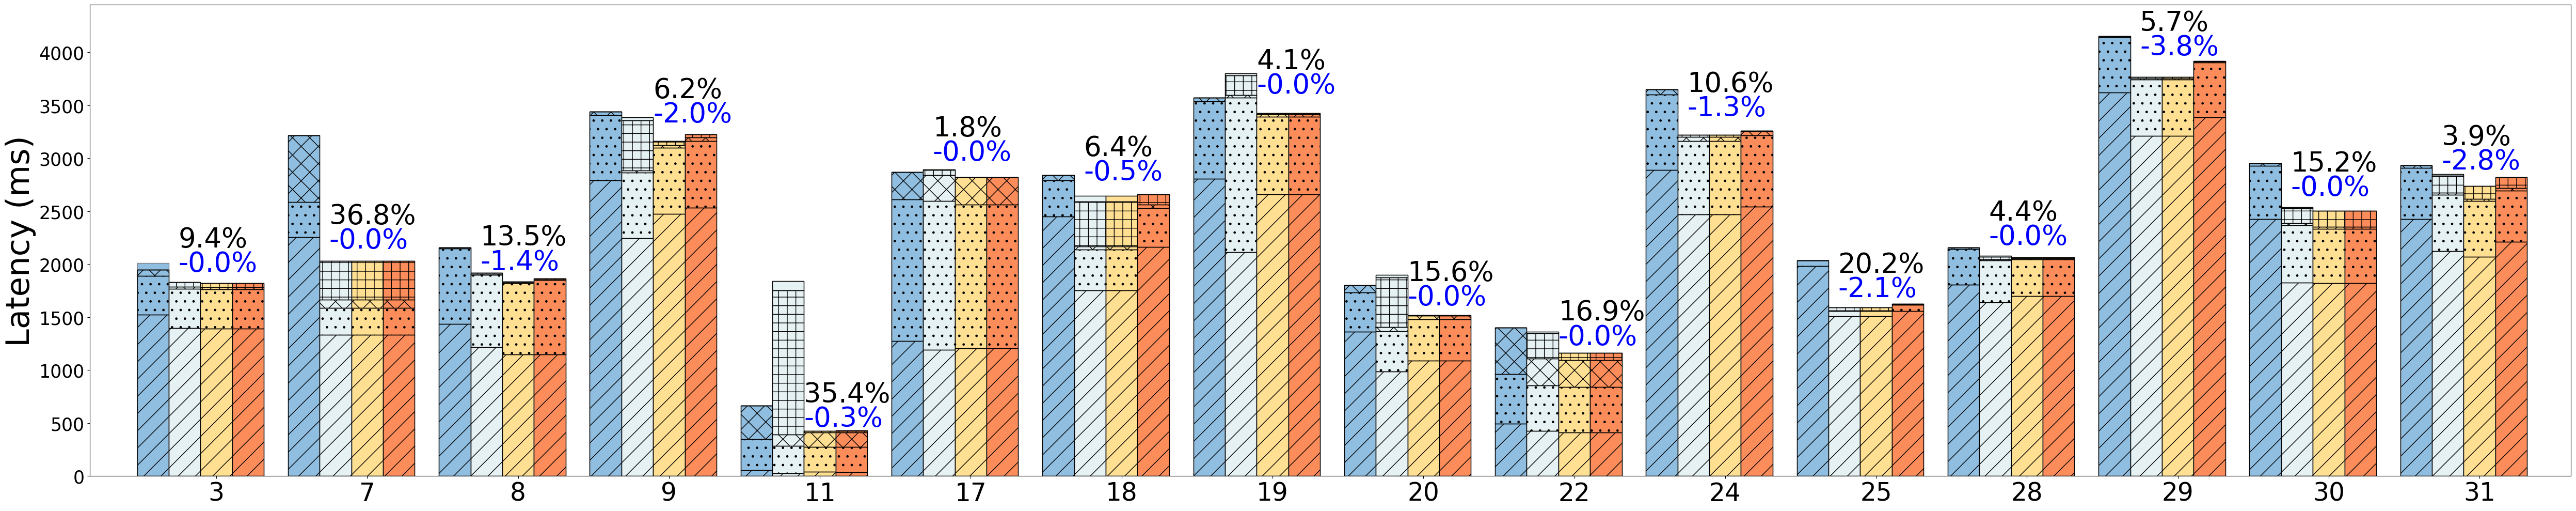

In [67]:
slm_best2= plot_data(combined_df2,query2)

In [68]:
total_slowdown = []
for item in slm_best1:
    total_slowdown.append(item)
for item in slm_best2:
    total_slowdown.append(item)
sum(total_slowdown)/len(total_slowdown)

np.float64(0.9471238799342252)

# JOB multi thread (Figure 18)

In [100]:
import csv
def parse_and_group(file_path):
    rows = []
    expected_columns = 12
    with open(file_path, 'r') as file:
        for line in file:
            try:
                parts = line.strip().split(',')
                if len(parts) != expected_columns or 'col' in line: 
                    continue
                rows.append(parts)
            except Exception as e:
                print(f"Skipping line due to error: {e}")
    output_csv = file_path+'.tmp'
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([f"col{i+1}" for i in range(expected_columns)])
        writer.writerows(rows)


    df = pd.read_csv(output_csv, dtype={
        'col1': 'str',     
        'col2': 'float64',  
        'col3': 'int64',    
        'col4': 'int64',     
        'col5': 'int64',    
        'col6': 'int64',    
        'col7': 'float64',   
        'col8': 'float64',   
        'col9': 'float64',   
        'col10': 'float64', 
        'col11': 'float64', 
        'col12': 'float64'  
    })
    df.columns =[ 'key', 'latency','result_size','thread_num', 'mat_strat', 'queue_thr', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
    df = df[df["thread_num"]!=1]
    grouped = df.loc[df.groupby(['key','thread_num'])['latency'].idxmin()]

    best_rows = []
    for thread_num, group in grouped.groupby('thread_num'):
        filtered_group = group[group['key'].isin(['EM', 'LM', 'select','best'])]
        if not filtered_group.empty:
            best_row = filtered_group.loc[filtered_group['latency'].idxmin()].copy()
            best_row['key'] = 'Best' 
            best_rows.append(best_row)
    if best_rows:
        grouped = pd.concat([grouped, pd.DataFrame(best_rows)], ignore_index=True)

    return grouped
    
early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
files = glob.glob('origin_data/job_result/*_multi_breakdown_new_0508.txt')
data_frames = []
for query_name in queries:
    file_path = f'origin_data/job_result/{query_name}_multi_breakdown_new_0508.txt'
    result = parse_and_group(file_path)
    result['query'] = query_name
    data_frames.append(result)
    
combined_df = pd.concat(data_frames, ignore_index=True)   

early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
files = glob.glob('origin_data/job_result/*.txt')
data_frames = []
for query_name in queries:
    result = pd.read_csv(f'origin_data/job_result/{query_name}.txt')
    result['query'] = query_name  # 添加查询名称列
    data_frames.append(result)
    
combined_df_ = pd.concat(data_frames, ignore_index=True)   

combined_df = pd.concat([combined_df, combined_df_])
    
combined_df


,key,latency,result_size,thread_num,mat_strat,queue_thr,map_building_time,materialize_time,sink_hash_join_time,others,io_time,total_latency_2,query
0,EM,57.2732,1.0,2.0,0.0,0.0,0.00,0.00,0.25,15.04,41.98,57.27,1d
1,EM,39.4380,1.0,4.0,0.0,0.0,0.00,0.00,0.04,17.92,21.48,39.44,1d
2,EM,29.8010,1.0,8.0,0.0,0.0,0.00,0.00,0.02,18.94,10.84,29.80,1d
3,EM,29.8010,1.0,16.0,0.0,0.0,0.00,0.00,0.02,18.94,10.84,29.80,1d
4,LM,35.9719,1.0,2.0,1.0,10.0,0.01,0.56,0.18,14.38,20.84,35.97,1d
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,LM,24.8440,0.0,1.0,1.0,10.0,0.00,0.00,0.00,20.79,4.06,24.84,32a
128,EM,388.2950,1.0,1.0,0.0,0.0,0.00,0.00,2.51,79.40,306.38,388.30,33a
129,select,308.8130,0.0,1.0,1.0,1000.0,0.00,0.00,1.99,75.15,231.67,308.81,33a
130,Best,307.1550,0.0,1.0,1.0,1000.0,0.00,0.00,2.00,78.03,227.12,307.15,33a


In [101]:
    
early_data = []
late_data = []
queries = ['7c','12b','13c','24a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
files = glob.glob('origin_data/job_result/*_multi_breakdown_new.txt')
data_frames = []
for query_name in queries:
    file_path = f'origin_data/job_result/{query_name}_multi_breakdown_new.txt'
    result = parse_and_group(file_path)
    result['query'] = query_name
    data_frames.append(result)
    
combined_df = pd.concat(data_frames, ignore_index=True)   

early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
files = glob.glob('origin_data/job_result/*.txt')
data_frames = []
for query_name in queries:
    result = pd.read_csv(f'origin_data/job_result/{query_name}.txt')
    result['query'] = query_name  # 添加查询名称列
    data_frames.append(result)
    
combined_df_ = pd.concat(data_frames, ignore_index=True)   

combined_df = pd.concat([combined_df, combined_df_])
    
combined_df


,key,latency,result_size,thread_num,mat_strat,queue_thr,map_building_time,materialize_time,sink_hash_join_time,others,io_time,total_latency_2,query
0,EM,1726.600,1.0,2.0,0.0,0.0,0.00,0.00,328.12,260.49,1137.99,1726.60,7c
1,EM,1158.520,1.0,4.0,0.0,0.0,0.00,0.00,202.55,229.81,726.16,1158.52,7c
2,EM,898.095,1.0,8.0,0.0,0.0,0.00,0.00,144.86,236.18,517.06,898.10,7c
3,EM,790.137,1.0,16.0,0.0,0.0,0.00,0.00,96.98,327.27,365.88,790.14,7c
4,LM,1130.960,1.0,2.0,1.0,10.0,0.83,204.81,40.90,181.82,702.60,1130.96,7c
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,LM,24.844,0.0,1.0,1.0,10.0,0.00,0.00,0.00,20.79,4.06,24.84,32a
128,EM,388.295,1.0,1.0,0.0,0.0,0.00,0.00,2.51,79.40,306.38,388.30,33a
129,select,308.813,0.0,1.0,1.0,1000.0,0.00,0.00,1.99,75.15,231.67,308.81,33a
130,Best,307.155,0.0,1.0,1.0,1000.0,0.00,0.00,2.00,78.03,227.12,307.15,33a


In [104]:
def plot_data(df, queries):
    import numpy as np
    import matplotlib.pyplot as plt


    color_map = ['#90BEE0','#E6F1F3', '#FFDF92', '#FC8C5A']
    strategies = ['EM', 'LM', 'Best', 'select']
    thread_nums = [1, 4, 8, 16]
    bar_width = 0.21 
    group_gap = 0.08  
    label_name = ['Pure EM', 'Pure LM','Optimal','SLM']

    total_groups = len(thread_nums)
    total_width = total_groups * len(strategies) * bar_width + (total_groups-1)*group_gap-0.6
    

    fig, ax = plt.subplots(figsize=(25, 6.2))
    index = np.arange(len(queries)) 

    for q_idx, query in enumerate(queries):

        base_x = q_idx * (total_width + 1)  

        for t_idx, thread_num in enumerate(thread_nums):

            group_x = base_x + t_idx*(len(strategies)*bar_width + group_gap)
            for s_idx, strategy in enumerate(strategies):
                data = df[(df['key']==strategy) & 
                         (df['thread_num']==thread_num) &
                         (df['query']==query)]
                

                x_pos = group_x + s_idx*bar_width
                
                ax.bar(x_pos, data['latency'], bar_width,
                       color=color_map[s_idx],
                       edgecolor='grey',
                       label= label_name[s_idx] if (q_idx==0 and t_idx==0) else "")
            
            group_data = {}
            for strategy in ['EM', 'Best']: 
                data = df[(df['key']==strategy) & 
                          (df['thread_num']==thread_num) &
                          (df['query']==query)]
                group_data[strategy] = data['latency'].values[0] if not data.empty else 0
            
            em_latency = group_data.get('EM', 0)
            best_latency = group_data.get('Best', 0)
            speedup = ((em_latency - best_latency) / em_latency * 100) if em_latency != 0 else 0
            if q_idx in [0,3]:
                 ax.text(group_x + len(strategies)*bar_width/2 - 1.4*bar_width , (best_latency)+100, '%.1f'%speedup+'%', fontsize = 32)
            else:
                ax.text(group_x + len(strategies)*bar_width/2 - 2*bar_width , (best_latency)+300, '%.1f'%speedup+'%', fontsize = 32)
            if q_idx!=3:
                plt.vlines(q_idx*(total_width+1) + total_width+0.7 ,0,4000, color = 'gray',linestyles='dashed',linewidth=3)

    ax.set_xlabel('Query7                       Query12                       Query13                       Query24', fontsize=34)
    ax.set_ylabel('Latency (ms)', fontsize=37)
    
    query_centers = [i*(total_width+1) + total_width/2 for i in range(len(queries))]
    ax.set_xticks(query_centers)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize=34)

    bar_centers = []
    for i in range(len(queries)):
        for j in range(4):
            bar_centers.append(i*(total_width+1)+ (bar_width*4+group_gap)*j+bar_width*2)
    ax.set_xticks(bar_centers)
    thread_labels = ["1","4","8","16"]*4
    ax.set_xticklabels(thread_labels, fontsize=30)
    ax.tick_params(axis='y', labelsize=28)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # 去重
    ax.legend(by_label.values(), by_label.keys(), 
             fontsize=30, ncol=1)
    # ax.set_xlim(-5*bar_width, len(queries) - 0.5 + 2.5*bar_width)

    plt.xlim(-0.3, len(queries)*(total_width+1)-0.15)
    plt.ylim(0,4000)
    plt.tight_layout()
    
    plt.savefig("paper_figure/job/multithread_job_pick.pdf", bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2939617/3775129167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)


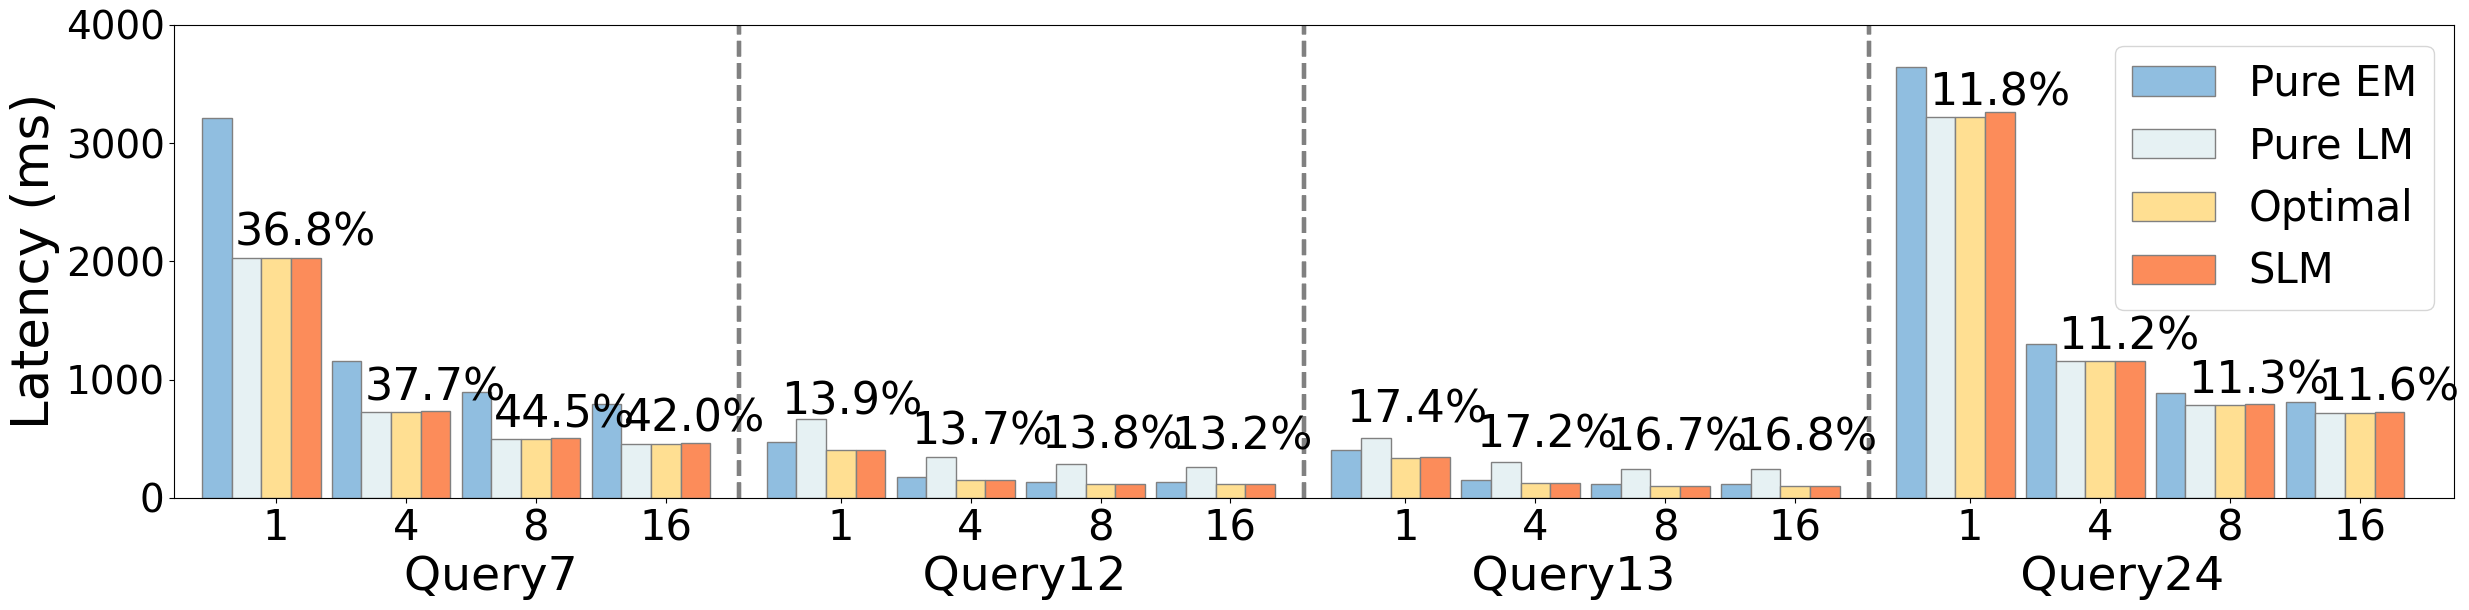

In [105]:
# thread_num = 4
# combined_df_new = combined_df[combined_df['thread_num']==thread_num]
query1 = ['7c','12b','13c','24a']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)
combined_df1 = combined_df1.sort_values('query')
# print(combined_df1)

plot_data(combined_df1,query1)

In [107]:
early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
files = glob.glob('origin_data/job_result/*_multi_breakdown_new_0508.txt')
data_frames = []
for query_name in queries:
    file_path = f'origin_data/job_result/{query_name}_multi_breakdown_new_0508.txt'
    result = parse_and_group(file_path)
    result['query'] = query_name
    data_frames.append(result)
    
combined_df = pd.concat(data_frames, ignore_index=True)   

early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
files = glob.glob('origin_data/job_result/*.txt')
data_frames = []
for query_name in queries:
    result = pd.read_csv(f'origin_data/job_result/{query_name}.txt')
    result['query'] = query_name  
    data_frames.append(result)
    
combined_df_ = pd.concat(data_frames, ignore_index=True)   

combined_df = pd.concat([combined_df, combined_df_])
    
combined_df


,key,latency,result_size,thread_num,mat_strat,queue_thr,map_building_time,materialize_time,sink_hash_join_time,others,io_time,total_latency_2,query
0,EM,57.2732,1.0,2.0,0.0,0.0,0.00,0.00,0.25,15.04,41.98,57.27,1d
1,EM,39.4380,1.0,4.0,0.0,0.0,0.00,0.00,0.04,17.92,21.48,39.44,1d
2,EM,29.8010,1.0,8.0,0.0,0.0,0.00,0.00,0.02,18.94,10.84,29.80,1d
3,EM,29.8010,1.0,16.0,0.0,0.0,0.00,0.00,0.02,18.94,10.84,29.80,1d
4,LM,35.9719,1.0,2.0,1.0,10.0,0.01,0.56,0.18,14.38,20.84,35.97,1d
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,LM,24.8440,0.0,1.0,1.0,10.0,0.00,0.00,0.00,20.79,4.06,24.84,32a
128,EM,388.2950,1.0,1.0,0.0,0.0,0.00,0.00,2.51,79.40,306.38,388.30,33a
129,select,308.8130,0.0,1.0,1.0,1000.0,0.00,0.00,1.99,75.15,231.67,308.81,33a
130,Best,307.1550,0.0,1.0,1.0,1000.0,0.00,0.00,2.00,78.03,227.12,307.15,33a


In [108]:
def plot_data(df, queries):
    import numpy as np
    import matplotlib.pyplot as plt

    color_map = ['#90BEE0','#E6F1F3', '#FFDF92', '#FC8C5A']
    strategies = ['EM', 'LM', 'Best', 'select']
    thread_nums = [1, 4, 8, 16]
    bar_width = 0.21  
    group_gap = 0.08   
    label_name = ['Pure EM', 'Pure LM','Optimal','SLM']
    total_groups = len(thread_nums)
    total_width = total_groups * len(strategies) * bar_width + (total_groups-1)*group_gap-0.6
    
    fig, ax = plt.subplots(figsize=(50, 10))
    index = np.arange(len(queries)) 

    for q_idx, query in enumerate(queries):
        base_x = q_idx * (total_width + 1) 
        
        for t_idx, thread_num in enumerate(thread_nums):
            group_x = base_x + t_idx*(len(strategies)*bar_width + group_gap)
        
            for s_idx, strategy in enumerate(strategies):

                data = df[(df['key']==strategy) & 
                         (df['thread_num']==thread_num) &
                         (df['query']==query)]
                
                x_pos = group_x + s_idx*bar_width
                
                ax.bar(x_pos, data['latency'], bar_width,
                       color=color_map[s_idx],
                       edgecolor='grey',
                       label= label_name[s_idx] if (q_idx==0 and t_idx==0) else "")
            
            group_data = {}
            for strategy in ['EM', 'Best']: 
                data = df[(df['key']==strategy) & 
                          (df['thread_num']==thread_num) &
                          (df['query']==query)]
                group_data[strategy] = data['latency'].values[0] if not data.empty else 0
            
            em_latency = group_data.get('EM', 0)
            best_latency = group_data.get('Best', 0)
            speedup = ((em_latency - best_latency) / em_latency * 100) if em_latency != 0 else 0
            if q_idx in [0,3]:
                 ax.text(group_x + len(strategies)*bar_width/2 - 1.4*bar_width , (best_latency)+100, '%.1f'%speedup+'%', fontsize = 32)
            else:
                ax.text(group_x + len(strategies)*bar_width/2 - 2*bar_width , (best_latency)+300, '%.1f'%speedup+'%', fontsize = 32)

            plt.vlines(q_idx*(total_width+1) + total_width+0.7 ,0,4000, color = 'gray',linestyles='dashed',linewidth=3)

    # ax.set_xlabel('query7                       query12                       query13                       query24', fontsize=34)
    ax.set_ylabel('Latency (ms)', fontsize=37)
    

    query_centers = [i*(total_width+1) + total_width/2 for i in range(len(queries))]
    ax.set_xticks(query_centers)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize=34)
    ax.tick_params(axis='y', labelsize=28)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  
    ax.legend(by_label.values(), by_label.keys(), 
             fontsize=30, ncol=1)
    plt.xlim(-0.3, len(queries)*(total_width+1)-0.15)
    # plt.ylim(0,2000)
    plt.tight_layout()
    
    plt.savefig("paper_figure/job/multithread_job_all_part3.pdf", bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2939617/1088547402.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)


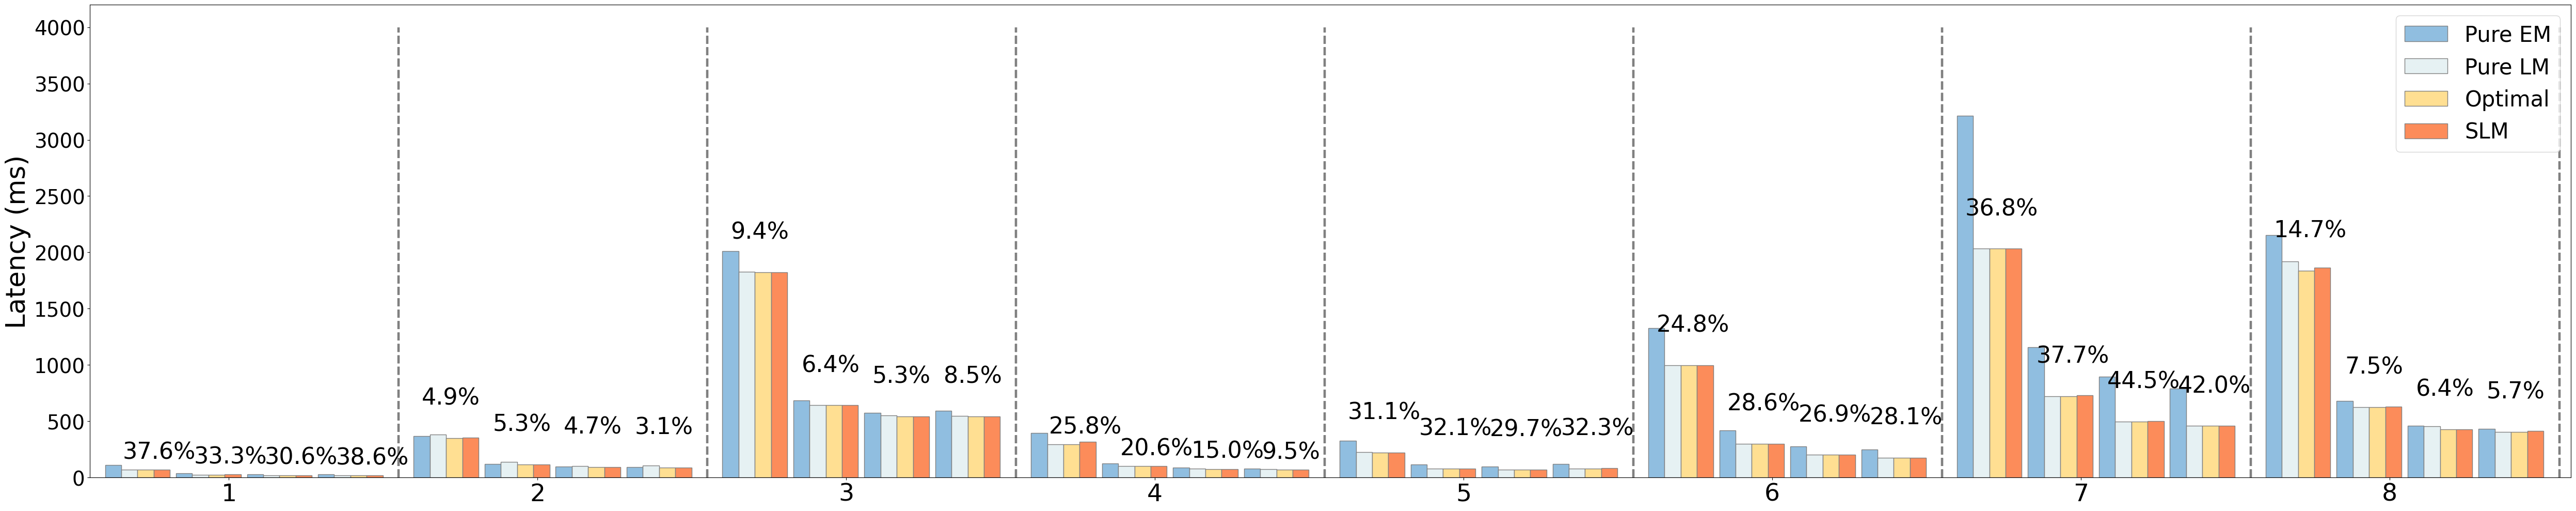

In [109]:

query1 = ['1d','2a','3a','4b','5a','6c','7c','8b']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)
combined_df1 = combined_df1.sort_values('query')


plot_data(combined_df1,query1)

/tmp/ipykernel_2939617/4192828360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)


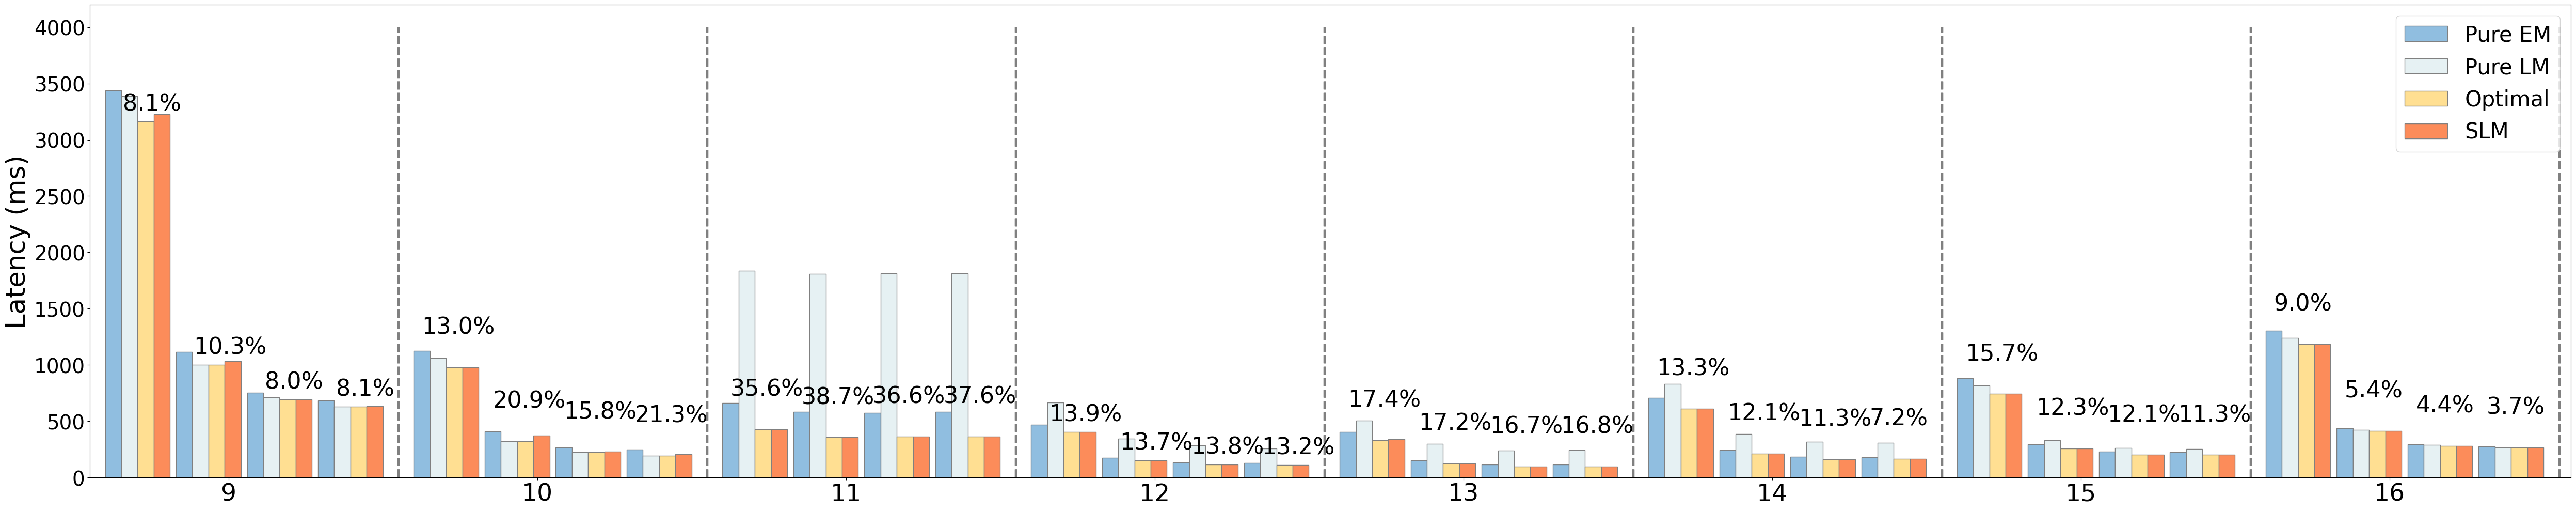

In [110]:
query1 = ['9a','10a','11d','12b','13c','14c','15d','16a']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)
combined_df1 = combined_df1.sort_values('query')
# print(combined_df1)

plot_data(combined_df1,query1)

/tmp/ipykernel_2939617/3764839304.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)


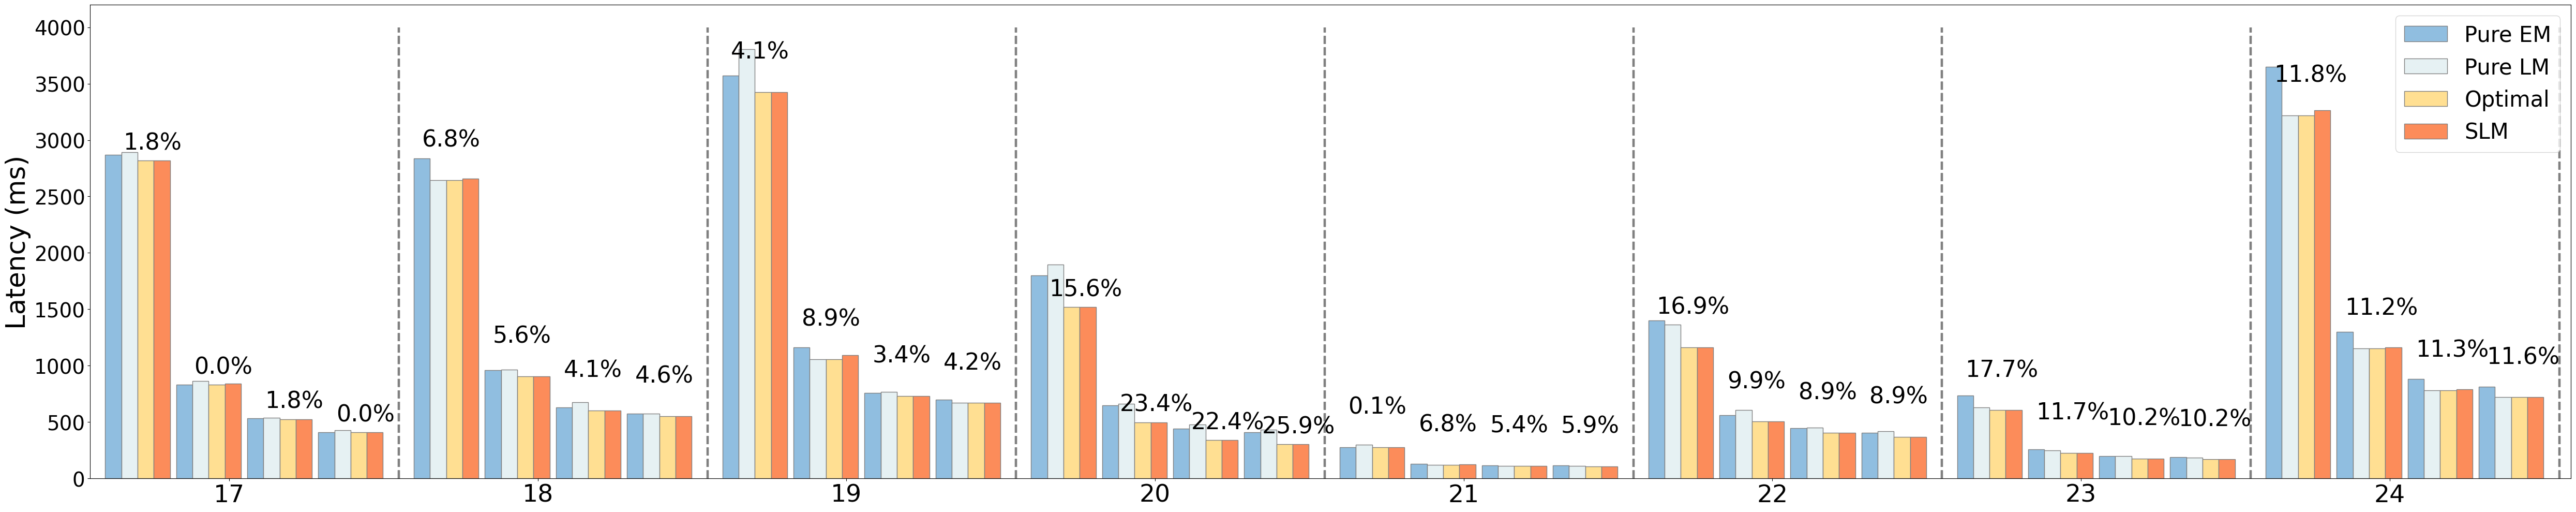

In [111]:
query1 = ['17f',
           '18a','19a','20a','21a','22d','23c','24a']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)
combined_df1 = combined_df1.sort_values('query')
# print(combined_df1)

plot_data(combined_df1,query1)

/tmp/ipykernel_2939617/4269749835.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)


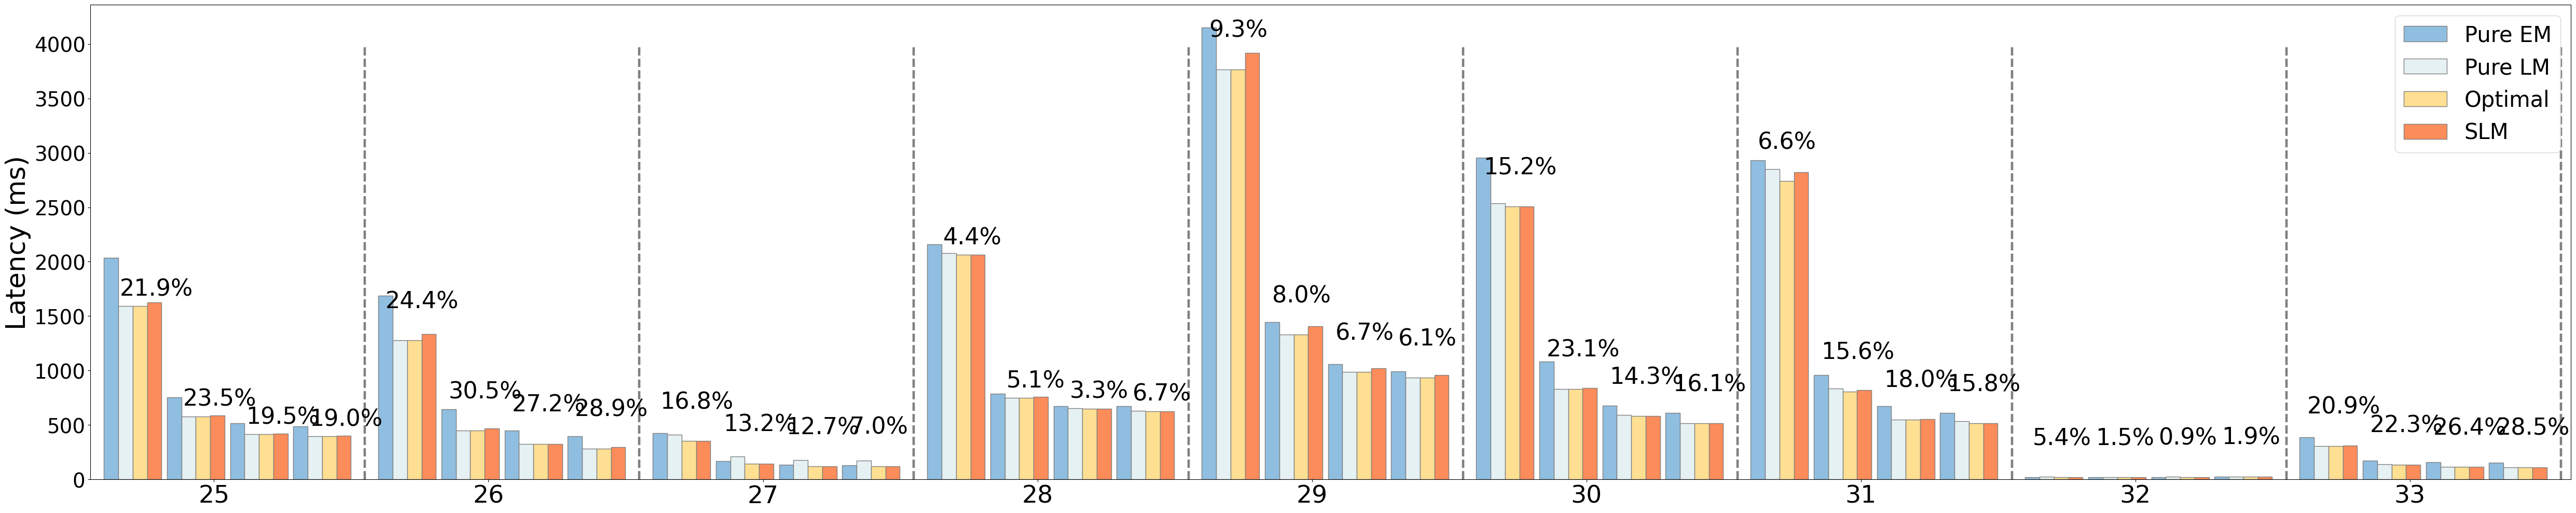

In [112]:
query1 = ['25b','26b','27b','28b','29c','30a','31c','32a','33a']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)
combined_df1 = combined_df1.sort_values('query')
# print(combined_df1)

plot_data(combined_df1,query1)

# JOB  warmup (Figure 19)

In [113]:
import csv
def parse_and_group(file_path):
    rows = []
    expected_columns = 12
    with open(file_path, 'r') as file:
        for line in file:
            try:
                parts = line.strip().split(',')
                if len(parts) != expected_columns or 'col' in line: 
                    continue
                rows.append(parts)
            except Exception as e:
                print(f"Skipping line due to error: {e}")
    output_csv = file_path+'.tmp'
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([f"col{i+1}" for i in range(expected_columns)])
        writer.writerows(rows)


    df = pd.read_csv(output_csv, dtype={
        'col1': 'str',     
        'col2': 'float64',  
        'col3': 'int64',    
        'col4': 'int64',     
        'col5': 'int64',    
        'col6': 'int64',    
        'col7': 'float64',   
        'col8': 'float64',   
        'col9': 'float64',   
        'col10': 'float64', 
        'col11': 'float64', 
        'col12': 'float64'  
    })
    df.columns =[ 'key', 'latency','result_size','thread_num', 'mat_strat', 'queue_thr', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
    grouped = df.loc[df.groupby('key')['latency'].idxmin()]
    best_row = grouped.loc[grouped['latency'].idxmin()].copy()
    best_row['key'] = 'Best'
    grouped = pd.concat([grouped, best_row.to_frame().T], ignore_index=True)

    return grouped
    
early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f',
           '18a','19a','20a','21a','22d','23c','24a','25b','26b','27b','28b','29c','30a','31c','32a','33a']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
files = glob.glob('origin_data/job_result/*_warmup_breakdown.txt')
data_frames = []
for query_name in queries:
    file_path = f'origin_data/job_result/{query_name}_warmup_breakdown.txt'
    result = parse_and_group(file_path)
    result['query'] = query_name
    data_frames.append(result)
    
combined_df = pd.concat(data_frames, ignore_index=True)   

combined_df
    

,key,latency,result_size,thread_num,mat_strat,queue_thr,map_building_time,materialize_time,sink_hash_join_time,others,io_time,total_latency_2,query
0,EM,37.572,1,1,0,0,0.0,0.0,0.14,15.97,21.46,37.57,1d
1,LM,34.6121,1,1,1,500,0.01,0.18,0.15,29.7,4.57,34.61,1d
2,select,30.23,1,1,1,500,0.01,0.12,0.14,26.3,3.98,30.23,1d
3,Best,30.23,1,1,1,500,0.01,0.12,0.14,26.3,3.98,30.23,1d
4,EM,106.095,1,1,0,0,0.0,0.0,6.05,53.79,46.25,106.09,2a
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,Best,5.7,1,1,1,10,0.0,0.0,0.0,5.71,0.0,5.7,32a
131,EM,107.124,1,1,0,0,0.0,0.0,0.86,51.83,54.43,107.12,33a
132,LM,94.6211,0,1,1,1000,0.0,0.0,0.69,48.41,45.52,94.62,33a
133,select,94.958,0,1,1,1000,0.0,0.0,0.7,48.46,45.8,94.96,33a


In [114]:
def plot_data(df, queries):
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    color_map=['#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']

    strategies = ['EM', 'LM','Best','select']
    bar_width = 0.21
    index = range(len(queries))
    
    fig, ax = plt.subplots(figsize=(50, 10))

    label_name = ['Pure EM', 'Pure LM','Best','Selective LM']
    for i, strategy in enumerate(strategies):
        strategy_data = df[df['key'] == strategy]
        latencies = strategy_data['latency']
        # print((latencies))
        io_time = strategy_data['io_time']
        others = strategy_data['others']
        sink_hash_join_time = strategy_data['sink_hash_join_time']
        materialize_time = strategy_data['materialize_time']
        map_building_time = strategy_data['map_building_time']

        ax.bar([x + i * bar_width for x in index], latencies, bar_width, color=color_map[i],edgecolor='grey', label = strategy)
        bottom = 0
        ax.bar([x + i * bar_width for x in index], io_time, bar_width,bottom = bottom, color='none',edgecolor='black',hatch='/', label = 'IO Time'if i == 3 else "")
        bottom += io_time
        ax.bar([x + i * bar_width for x in index], others, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='.', label='Others'if i == 3 else "")
        bottom += others
        ax.bar([x + i * bar_width for x in index], sink_hash_join_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='x', label = 'Hash Build Time'if i == 3 else "")
        bottom += sink_hash_join_time
        ax.bar([x + i * bar_width for x in index], materialize_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='+', label = 'Materialize Time'if i == 3 else "")
        bottom += materialize_time
        ax.bar([x + i * bar_width for x in index], map_building_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='', label = 'Map Building Time'if i == 3 else "")
    
    late = np.array(df[df['key'] == 'select']['latency'])
    early = np.array(df[df['key'] == 'LM']['latency'])
    enhance = (early - late)*100/early
    for i in range(len(index)):
        if index[i] in [3,4,6,7,8,9]:
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05, '%.1f'%enhance[i]+'%', fontsize = 38)
        # elif index[i] in [9,10]:
        #     plt.text(index[i] + bar_width*0.6 , late[i]*1.25, '%.1f'%enhance[i]+'%', fontsize = 38)
        else:
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05, '%.1f'%enhance[i]+'%', fontsize = 38)
    print(sum(enhance)/len(enhance))
    
    ax.set_xlabel('JOB Query', fontsize = 45)
    ax.set_ylabel('Latency (ms)', fontsize = 45)
    # ax.set_title('Latency Comparison for Different Queries', fontsize = 45)
    ax.set_xticks([i + bar_width * 2 for i in index])
    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize = 35)
    ax.set_xlim(-2*bar_width, len(queries) - 0.5 + 2.5*bar_width)
    ax.set_ylim(0,2000)
    
    fig_name = 'warmup_job1'
    plt.tight_layout()
    plt.savefig(f"paper_figure/job/{fig_name}.pdf",bbox_inches='tight')
    plt.show()
    return enhance

12.938578881419497


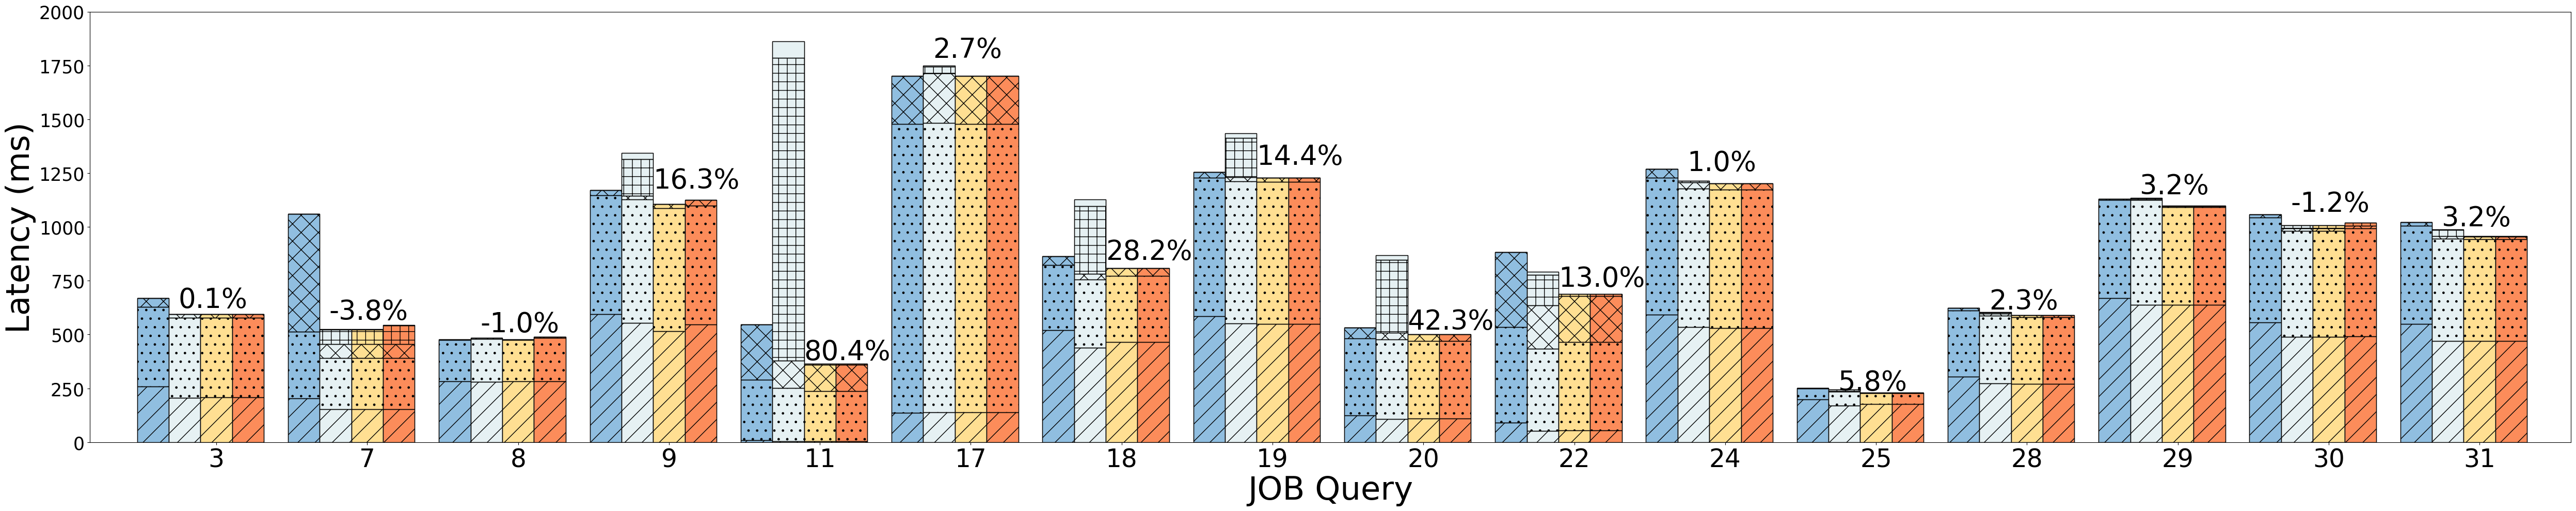

In [115]:
query2 = ['3a','7c','8b','9a','11d','17f',
           '18a','19a','20a','22d','24a','25b','28b','29c','30a','31c']
combined_df2 = combined_df[combined_df['query'].isin( query2)]
# print(combined_df2[combined_df2['key']=='LM'])
enhance1 = plot_data(combined_df2,query2)

In [116]:
def plot_data(df, queries):
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    color_map=['#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']

    strategies = ['EM', 'LM','Best','select']
    bar_width = 0.21
    index = range(len(queries))
    
    fig, ax = plt.subplots(figsize=(50, 10))

    label_name = ['Pure EM', 'Pure LM','Best','Selective LM']
    for i, strategy in enumerate(strategies):
        strategy_data = df[df['key'] == strategy]
        latencies = strategy_data['latency']
        # print((latencies))
        io_time = strategy_data['io_time']
        others = strategy_data['others']
        sink_hash_join_time = strategy_data['sink_hash_join_time']
        materialize_time = strategy_data['materialize_time']
        map_building_time = strategy_data['map_building_time']

        ax.bar([x + i * bar_width for x in index], latencies, bar_width, color=color_map[i],edgecolor='grey', label = strategy)
        bottom = 0
        ax.bar([x + i * bar_width for x in index], io_time, bar_width,bottom = bottom, color='none',edgecolor='black',hatch='/', label = 'I/O Time'if i == 3 else "")
        bottom += io_time
        ax.bar([x + i * bar_width for x in index], others, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='.', label='Others'if i == 3 else "")
        bottom += others
        ax.bar([x + i * bar_width for x in index], sink_hash_join_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='x', label = 'Hash Build Time'if i == 3 else "")
        bottom += sink_hash_join_time
        ax.bar([x + i * bar_width for x in index], materialize_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='+', label = 'Materialize Time'if i == 3 else "")
        bottom += materialize_time
        ax.bar([x + i * bar_width for x in index], map_building_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='', label = 'Map Building Time'if i == 3 else "")
    
    late = np.array(df[df['key'] == 'Best']['latency'])
    early = np.array(df[df['key'] == 'EM']['latency'])
    enhance = (early - late)*100/early
    for i in range(len(index)):
        if index[i] in [1,6,7,8,9,12,13,14]:
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05, '%.1f'%enhance[i]+'%', fontsize = 38)
        else:
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05, '%.1f'%enhance[i]+'%', fontsize = 38)
    print(sum(enhance)/len(enhance))
    
    ax.set_xlabel('JOB Query', fontsize = 45)
    ax.set_ylabel('Latency (ms)', fontsize = 45)
    # ax.set_title('Latency Comparison for Different Queries', fontsize = 45)
    ax.set_xticks([i + bar_width * 2 for i in index])
    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize = 35)
    ax.set_xlim(-2*bar_width, len(queries) - 0.5 + 2.5*bar_width)
    ax.set_ylim(0,550)
    ax.legend(fontsize=35,ncol=2)
    
    fig_name = 'warmup_job2'
    plt.tight_layout()
    plt.savefig(f"paper_figure/job/{fig_name}.pdf",bbox_inches='tight')
    plt.show()
    return enhance


16.244420015397676


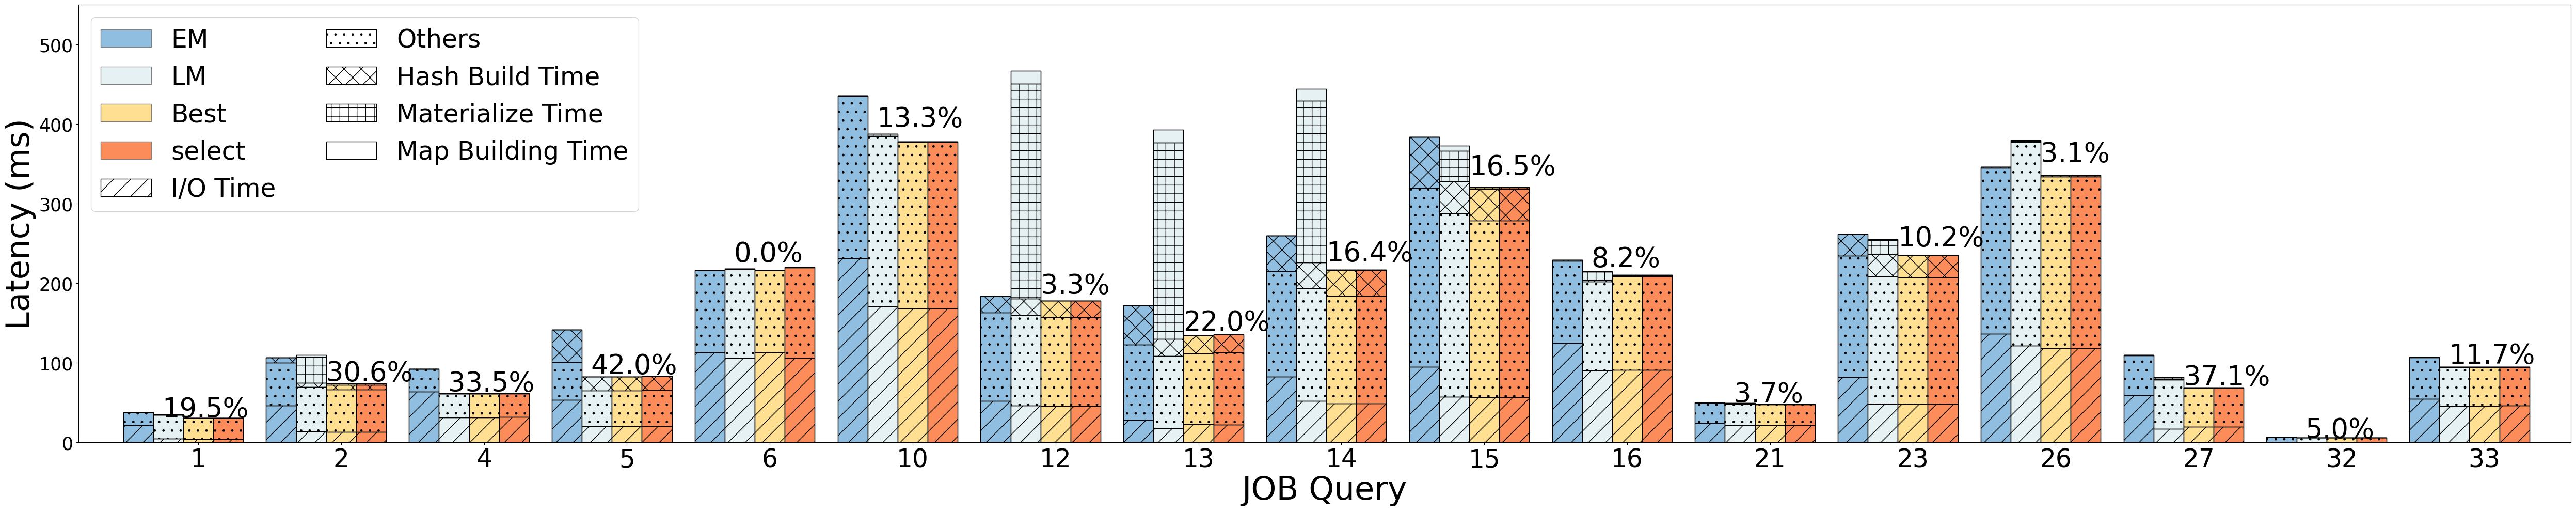

In [117]:
total_jobs = ['1d','2a','4b','5a','6c','10a','12b','13c','14c','15d','16a','21a','23c','26b','27b','32a','33a']
query2 = ['3a','7c','8b','9a','11d','17f',
           '18a','19a','20a','22d','24a','25b','28b','29c','30a','31c']
query1 = ['1d','2a','4b','5a','6c','10a','12b','13c','14c','15d','16a','21a','23c','26b','27b','32a','33a']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
# print(combined_df2[combined_df2['key']=='LM'])
enhance2 = plot_data(combined_df1,query1)

In [118]:
enhance = list(enhance1) + list(enhance2)
sum(enhance)/len(enhance)

np.float64(14.641587950438558)

In [119]:
def plot_data(df, queries):
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    color_map=['#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']

    strategies = ['EM', 'LM','Best','select']
    bar_width = 0.21
    index = range(len(queries))
    
    fig, ax = plt.subplots(figsize=(16, 7))

    label_name = ['Pure EM', 'Pure LM','Best','Selective LM']
    for i, strategy in enumerate(strategies):
        strategy_data = df[df['key'] == strategy]
        latencies = strategy_data['latency']
        # print((latencies))
        io_time = strategy_data['io_time']
        others = strategy_data['others']
        sink_hash_join_time = strategy_data['sink_hash_join_time']
        materialize_time = strategy_data['materialize_time']
        map_building_time = strategy_data['map_building_time']

        ax.bar([x + i * bar_width for x in index], latencies, bar_width, color=color_map[i],edgecolor='grey', label = strategy)
        bottom = 0
        ax.bar([x + i * bar_width for x in index], io_time, bar_width,bottom = bottom, color='none',edgecolor='black',hatch='/', label = 'IO Time'if i == 3 else "")
        bottom += io_time
        ax.bar([x + i * bar_width for x in index], others, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='.', label='Others'if i == 3 else "")
        bottom += others
        ax.bar([x + i * bar_width for x in index], sink_hash_join_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='x', label = 'Hash Build Time'if i == 3 else "")
        bottom += sink_hash_join_time
        ax.bar([x + i * bar_width for x in index], materialize_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='+', label = 'Materialize Time'if i == 3 else "")
        bottom += materialize_time
        ax.bar([x + i * bar_width for x in index], map_building_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='', label = 'Map Building Time'if i == 3 else "")
    
    late = np.array(df[df['key'] == 'Best']['latency'])
    early = np.array(df[df['key'] == 'EM']['latency'])
    enhance = (early - late)*100/early
    for i in range(len(index)):
        if index[i] in [0,1,4,5]:
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05, '%.1f'%enhance[i]+'%', fontsize = 33)
        else:
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05, '%.1f'%enhance[i]+'%', fontsize = 33)
    print(sum(enhance)/len(enhance))
    plt.vlines(2.85,0,1400, color = 'gray',linestyles='dashed',linewidth=3)
    
    ax.set_xlabel('JOB Query', fontsize = 35)
    ax.set_ylabel('Latency (ms)', fontsize = 35)
    # ax.set_title('Latency Comparison for Different Queries', fontsize = 45)
    ax.set_xticks([i + bar_width * 2 for i in index])
    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticklabels([q[:-1] for q in queries], fontsize = 32)
    ax.set_xlim(-2*bar_width, len(queries) - 0.5 + 2.5*bar_width)
    ax.set_ylim(0,1400)
    # ax.legend(fontsize=35,ncol=2)
    
    fig_name = 'warmup_job_pick'
    plt.tight_layout()
    plt.savefig(f"paper_figure/job/{fig_name}.pdf",bbox_inches='tight')
    plt.show()
    return enhance


/tmp/ipykernel_2939617/2236942320.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)


18.237505092202333


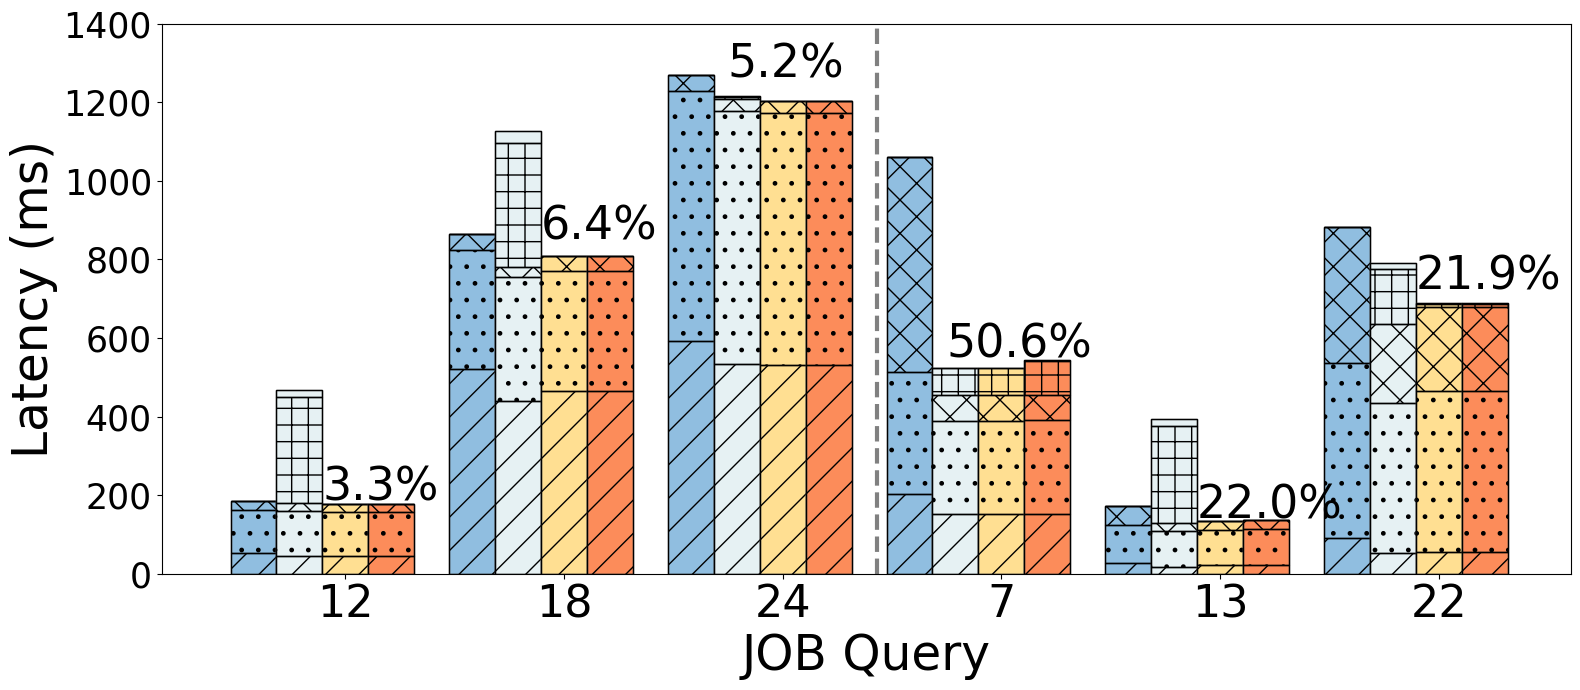

In [120]:
query1 = ['12b','18a','24a','7c','13c','22d']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
combined_df1['query'] = pd.Categorical(combined_df1['query'], categories=query1, ordered=True)
combined_df1 = combined_df1.sort_values('query')

# print(combined_df2[combined_df2['key']=='LM'])
enhance2 = plot_data(combined_df1,query1)

# TPCDS (Figure 17)

In [121]:
import csv
def parse_and_group(file_path):
    rows = []
    expected_columns = 12
    with open(file_path, 'r') as file:
        for line in file:
            try:
                parts = line.strip().split(',')
                if len(parts) != expected_columns or 'col' in line: 
                    continue
                rows.append(parts)
            except Exception as e:
                print(f"Skipping line due to error: {e}")
    output_csv = file_path+'.tmp'
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([f"col{i+1}" for i in range(expected_columns)])
        writer.writerows(rows)


    df = pd.read_csv(output_csv, dtype={
        'col1': 'str',     
        'col2': 'float64',  
        'col3': 'int64',    
        'col4': 'int64',     
        'col5': 'int64',    
        'col6': 'int64',    
        'col7': 'float64',   
        'col8': 'float64',   
        'col9': 'float64',   
        'col10': 'float64', 
        'col11': 'float64', 
        'col12': 'float64'  
    })
    df.columns =[ 'key', 'latency','result_size','thread_num', 'mat_strat', 'queue_thr', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']

    grouped = df.loc[df.groupby('key')['latency'].idxmin()]
    best_row = grouped.loc[grouped['latency'].idxmin()].copy()
    best_row['key'] = 'Best'
    grouped = pd.concat([grouped, best_row.to_frame().T], ignore_index=True)

    return grouped
    
early_data = []
late_data = []
queries = ['q3', 'q4', 'q6', 'q11', 'q13', 'q19', 'q24', 'q25', 'q27','q37','q42','q52','q55', 'q68', 'q72', 'q81', 'q83', 'q85','q99']

# queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d']
files = glob.glob('origin_data/tpcds/*_breakdown.txt')
data_frames = []
for query_name in queries:
    file_path = f'origin_data/tpcds/{query_name}_breakdown.txt'
    result = parse_and_group(file_path)
    result['query'] = query_name
    data_frames.append(result)
    
combined_df = pd.concat(data_frames, ignore_index=True)   

combined_df
    

,key,latency,result_size,thread_num,mat_strat,queue_thr,map_building_time,materialize_time,sink_hash_join_time,others,io_time,total_latency_2,query
0,EM,927.034,67,1,0,0,0.0,0.0,0.82,85.32,840.89,927.03,q3
1,LM,766.382,67,1,1,10,0.13,158.02,0.84,85.64,521.74,766.38,q3
2,select,761.694,67,1,1,10,0.11,144.33,2.06,85.72,529.48,761.69,q3
3,Best,761.694,67,1,1,10,0.11,144.33,2.06,85.72,529.48,761.69,q3
4,EM,1518.61,1238,1,0,0,0.0,0.0,26.92,97.61,1394.08,1518.61,q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Best,674.205,20,1,1,100,0.07,83.5,59.13,157.04,374.47,674.21,q85
76,EM,547.706,72,1,0,0,0.0,0.0,1.94,301.28,244.49,547.71,q99
77,LM,514.538,72,1,1,100,0.02,0.3,2.53,309.07,202.61,514.54,q99
78,select,509.284,72,1,1,100,0.02,0.6,1.47,304.76,202.43,509.28,q99


In [124]:
def plot_data(df, queries):
    color_map=['#4B74B2','#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']
    color_map=['#90BEE0','#E6F1F3','#FFDF92','#FC8C5A','#DB3124']

    strategies = ['EM', 'LM','Best','select']
    bar_width = 0.21
    index = range(len(queries))
    
    fig, ax = plt.subplots(figsize=(50, 10))

    label_name = ['Pure EM', 'Pure LM','Optimal','Selective LM']
    for i, strategy in enumerate(strategies):
        strategy_data = df[df['key'] == strategy]
        latencies = strategy_data['latency']
        # print((strategy_data))
        io_time = strategy_data['io_time']
        others = strategy_data['others']
        sink_hash_join_time = strategy_data['sink_hash_join_time']
        materialize_time = strategy_data['materialize_time']
        map_building_time = strategy_data['map_building_time']

        ax.bar([x + i * bar_width for x in index], latencies, bar_width, color=color_map[i],edgecolor='grey', label = label_name[i])
        bottom = 0
        ax.bar([x + i * bar_width for x in index], io_time, bar_width,bottom = bottom, color='none',edgecolor='black',hatch='/', label = 'I/O Time'if i == 3 else "")
        bottom += io_time
        ax.bar([x + i * bar_width for x in index], others, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='.', label='Others'if i == 3 else "")
        bottom += others
        ax.bar([x + i * bar_width for x in index], sink_hash_join_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='x', label = 'Hash Build Time'if i == 3 else "")
        bottom += sink_hash_join_time
        ax.bar([x + i * bar_width for x in index], materialize_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='+', label = 'Materialize Time'if i == 3 else "")
        bottom += materialize_time
        ax.bar([x + i * bar_width for x in index], map_building_time, bar_width, bottom=bottom, color='none',edgecolor='black',hatch='', label = 'Map Building Time'if i == 3 else "")
    
    late = np.array(df[df['key'] == 'Best']['latency'])
    early = np.array(df[df['key'] == 'EM']['latency'])
    slm = np.array(df[df['key'] == 'select']['latency'])
    enhance = (early - slm)*100/early
    slm_best = (slm-late)*100/slm
    for i in range(len(index)):
        if index[i] in [2,4,5,8,10,11,12,14,15]:
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05+200, '%.1f'%enhance[i]+'%', fontsize = 44)
            plt.text(index[i] + bar_width*1.5 , late[i]*1.05+20, '-%.1f'%slm_best[i]+'%', fontsize = 44,color='blue')
        else:
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05+200, '%.1f'%enhance[i]+'%', fontsize = 44)
            plt.text(index[i] + bar_width*0.8 , late[i]*1.05+20, '-%.1f'%slm_best[i]+'%', fontsize = 44,color='blue')
    print(sum(slm_best)/len(slm_best), max(slm_best))
    # print(enhance,sum(enhance)/8)
    
    # ax.set_xlabel('TPCDS Query', fontsize = 45)
    ax.set_ylabel('Latency (ms)', fontsize = 45)
    # ax.set_title('Latency Comparison for Different Queries', fontsize = 45)
    ax.set_xticks([i + bar_width * 2 for i in index])
    ax.tick_params(axis='y', labelsize=30)
    ax.set_xticklabels([q for q in queries], fontsize = 42)
    ax.set_xlim(-2*bar_width, len(queries) - 0.5 + 2.5*bar_width)
    # ax.set_ylim(0,2000)
    ax.legend(fontsize=40,ncol=2)
    
    fig_name = 'tpcds'
    plt.tight_layout()
    plt.savefig(f"paper_figure/tpcds/{fig_name}.pdf",bbox_inches='tight')
    plt.show()


1.2479308971997205 5.032828564300993


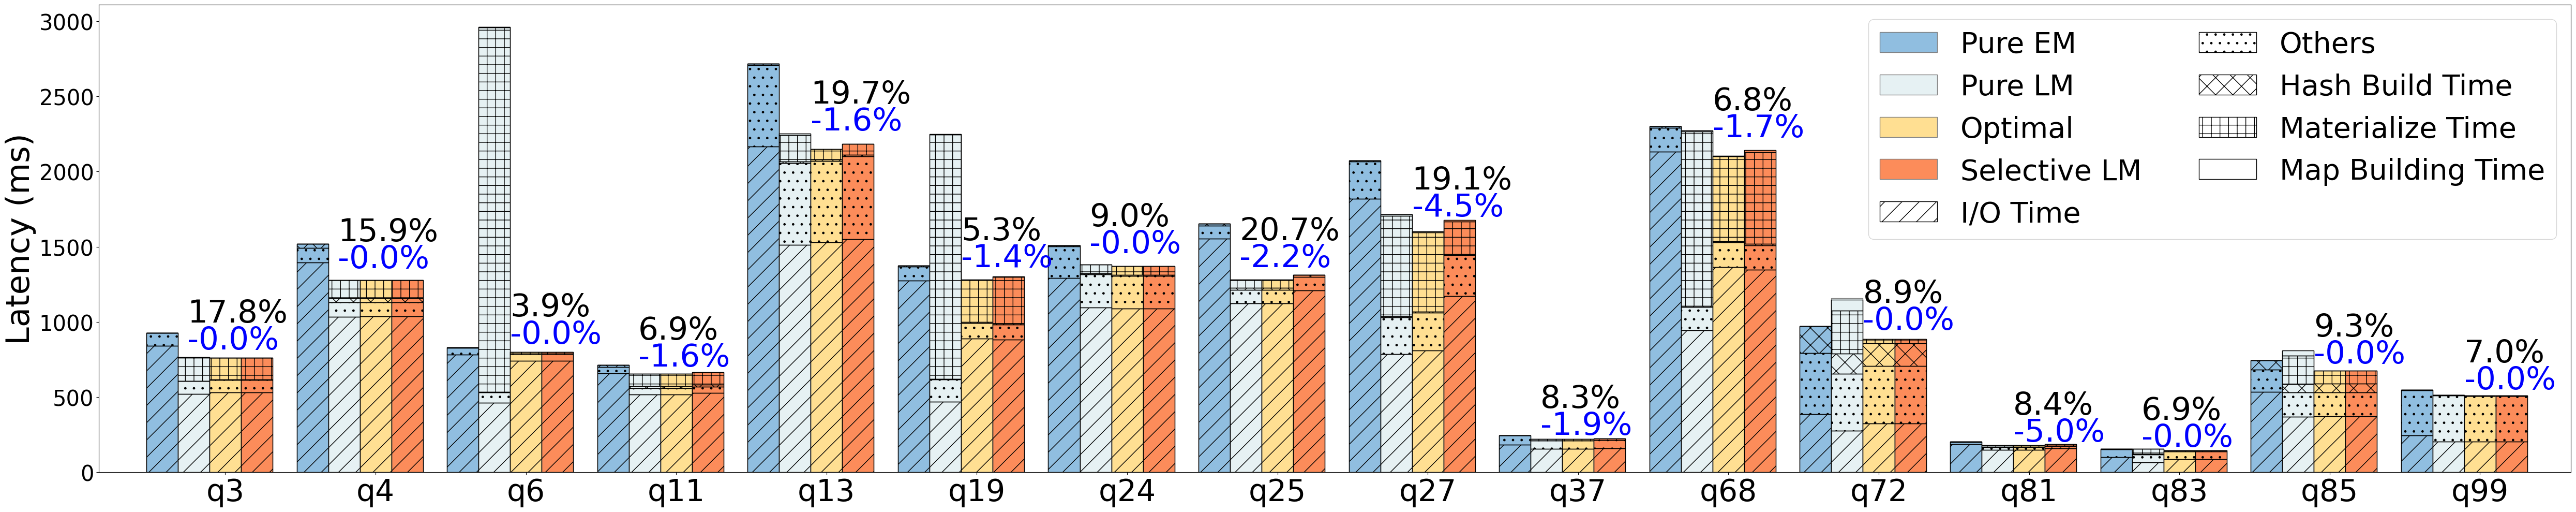

In [125]:
query1 = ['q3', 'q4', 'q6', 'q11', 'q13', 'q19', 'q24', 'q25', 'q27','q37', 'q68', 'q72', 'q81', 'q83', 'q85','q99']
combined_df1 = combined_df[combined_df['query'].isin( query1)]
# print(combined_df2[combined_df2['key']=='LM'])
plot_data(combined_df1,query1)